#  Electricity Demand Forecasting from the Database

This notebook shows how energy data stored in MySQL can be used for predictive analysis.

**Task:** predict electricity demand **1 hour ahead** at 5-minute resolution.

**Approach:**
1. Build the model features **inside MySQL** with SQL window functions (`LAG`), so the database does the time-series preparation.
2. Load the result into pandas.
3. Train on 2019–2020, test on 2021 (a time-based split, no shuffling).
4. Compare a naive baseline, Linear Regression, and Random Forest.

In [4]:
pip install scikit-learn matplotlib ipykernel

Note: you may need to restart the kernel to use updated packages.


In [7]:
%pip install sqlalchemy pymysql cryptography scikit-learn matplotlib pandas

  Using cached pymysql-1.2.3-py3-none-any.whl.metadata (4.2 kB)
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ------------------------ --------------- 1.3/2.2 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 7.2 MB/s  0:00:00
Using cached pymysql-1.2.3-py3-none-any.whl (46 kB)
   ---------------------------------------- 0.0/3.8 MB ? eta -:--:--
   ------------------- -------------------- 1.8/3.8 MB 10.0 MB/s eta 0:00:01
   -------------------------------------- - 3.7/3.8 MB 9.9 MB/s eta 0:00:01
   ---------------------------------------- 3.8/3.8 MB 8.8 MB/s  0:00:00

   -------- ------------------------------- 1/5 [greenlet]
  Attempting uninstall: cffi
   -------- ------------------------------- 1/5 [greenlet]
    Found existing installation: cffi 1.17.1
   -------- ------------------------------- 1/5 [greenlet]
    Uninstalling cffi-1.17.1:
   -------- --------

In [8]:
import os, time
from getpass import getpass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

RESULTS_DIR = "../results"          # notebook lives in notebooks/
os.makedirs(RESULTS_DIR, exist_ok=True)

## 1. Connect to MySQL

In [9]:
engine = create_engine(URL.create(
    "mysql+pymysql",
    username="root",
    password="root",
    host="localhost",
    port=3306,
    database="energydb",
))

## 2. Build features in SQL

Each row is predicting demand at time *t*. To forecast 1 hour ahead, every demand feature must already be known 1 hour earlier:

| Feature | Meaning |
|---|---|
| `demand_lag_1h` | demand 1 hour earlier (12 readings back) |
| `demand_lag_24h` | demand at the same time yesterday (288 readings back) |
| `demand_lag_7d` | demand at the same time last week (2016 readings back) |
| `hour_of_day`, `day_id`, `month` | calendar effects |
| `temperature`, `humidity`, `ghi` | weather (assumed available from a weather forecast) |

In [10]:
feature_sql = """
SELECT reading_time,
       HOUR(reading_time) + MINUTE(reading_time) / 60 AS hour_of_day,
       day_id,
       MONTH(reading_time)                            AS month,
       temperature,
       humidity,
       ghi,
       LAG(electric_demand, 12)   OVER w AS demand_lag_1h,
       LAG(electric_demand, 288)  OVER w AS demand_lag_24h,
       LAG(electric_demand, 2016) OVER w AS demand_lag_7d,
       electric_demand
FROM energy_reading
WINDOW w AS (ORDER BY reading_time)
ORDER BY reading_time
"""

start = time.perf_counter()
df = pd.read_sql(feature_sql, engine, parse_dates=["reading_time"])
print(f"Query + load: {time.perf_counter() - start:.1f} s, {len(df):,} rows")

# The first week has no 7-day lag, so drop those rows
df = df.dropna().reset_index(drop=True)
print(f"Rows after dropping incomplete lags: {len(df):,}")
df.head()

Query + load: 15.3 s, 315,648 rows
Rows after dropping incomplete lags: 313,632


,reading_time,hour_of_day,day_id,month,temperature,humidity,ghi,demand_lag_1h,demand_lag_24h,demand_lag_7d,electric_demand
0,2019-01-08 00:00:00,0.0000,1,1,9.24,77.232,0.0,22972.0,21115.0,22216.0,21490
1,2019-01-08 00:05:00,0.0833,1,1,9.26,77.124,0.0,22859.0,21050.0,22106.0,21411
2,2019-01-08 00:10:00,0.1667,1,1,9.24,77.234,0.0,22752.0,21010.0,22130.0,21389
3,2019-01-08 00:15:00,0.2500,1,1,9.22,77.344,0.0,22579.0,20895.0,22040.0,21266
4,2019-01-08 00:20:00,0.3333,1,1,9.22,77.372,0.0,22465.0,20713.0,21963.0,21206


## 3. Time-based train/test split

In [11]:
FEATURES = ["hour_of_day", "day_id", "month", "temperature", "humidity", "ghi",
            "demand_lag_1h", "demand_lag_24h", "demand_lag_7d"]
TARGET = "electric_demand"

train = df[df["reading_time"] <  "2021-01-01"]
test  = df[df["reading_time"] >= "2021-01-01"]
X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]
print(f"Train: {len(train):,} rows (2019-2020) | Test: {len(test):,} rows (2021)")

Train: 208,512 rows (2019-2020) | Test: 105,120 rows (2021)


## 4. Train and evaluate models

In [12]:
def evaluate(name, y_true, y_pred, seconds=0.0):
    return {"model": name,
            "MAE_MW":  round(mean_absolute_error(y_true, y_pred), 0),
            "RMSE_MW": round(np.sqrt(mean_squared_error(y_true, y_pred)), 0),
            "MAPE_%":  round(100 * np.mean(np.abs((y_true - y_pred) / y_true)), 2),
            "train_s": round(seconds, 1)}

results, predictions = [], {}

# Baseline: assume demand stays the same as 1 hour ago
predictions["Baseline (1h ago)"] = test["demand_lag_1h"].values
results.append(evaluate("Baseline (1h ago)", y_test, predictions["Baseline (1h ago)"]))

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=20,
                                           min_samples_leaf=5, n_jobs=-1,
                                           random_state=42),
}
for name, model in models.items():
    start = time.perf_counter()
    model.fit(X_train, y_train)
    seconds = time.perf_counter() - start
    predictions[name] = model.predict(X_test)
    results.append(evaluate(name, y_test, predictions[name], seconds))

results_df = pd.DataFrame(results)
results_df

,model,MAE_MW,RMSE_MW,MAPE_%,train_s
0,Baseline (1h ago),934.0,1127.0,3.71,0.0
1,Linear Regression,697.0,875.0,2.83,0.2
2,Random Forest,255.0,350.0,1.05,23.7


## 5. Actual vs predicted demand (one week in August 2021)

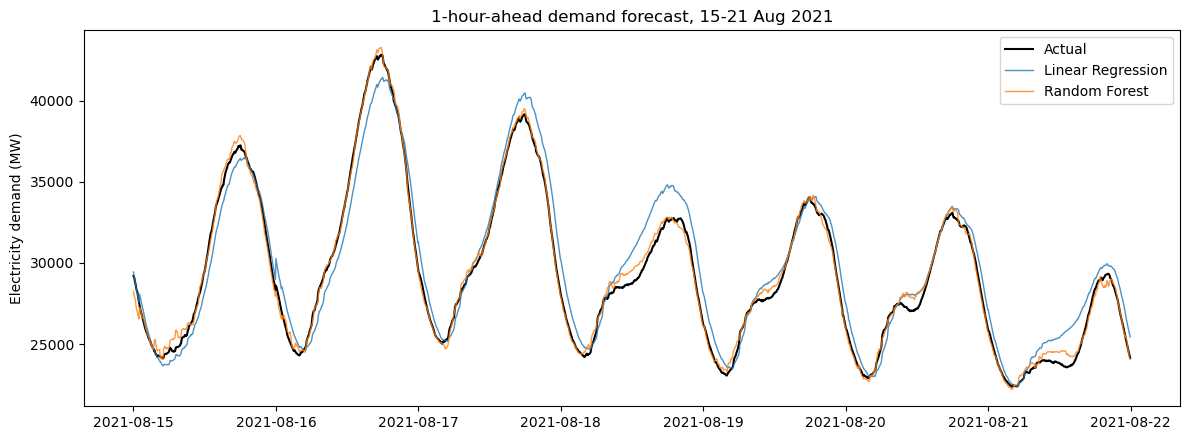

In [13]:
mask = (test["reading_time"] >= "2021-08-15") & (test["reading_time"] < "2021-08-22")
week = test[mask]

plt.figure(figsize=(12, 4.5))
plt.plot(week["reading_time"], week[TARGET], label="Actual", color="black", linewidth=1.5)
for name in ["Linear Regression", "Random Forest"]:
    plt.plot(week["reading_time"], predictions[name][mask.values], label=name,
             linewidth=1, alpha=0.8)
plt.ylabel("Electricity demand (MW)")
plt.title("1-hour-ahead demand forecast, 15-21 Aug 2021")
plt.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/forecast_week.png", dpi=150)
plt.show()

## 6. Which features matter most? (Random Forest)

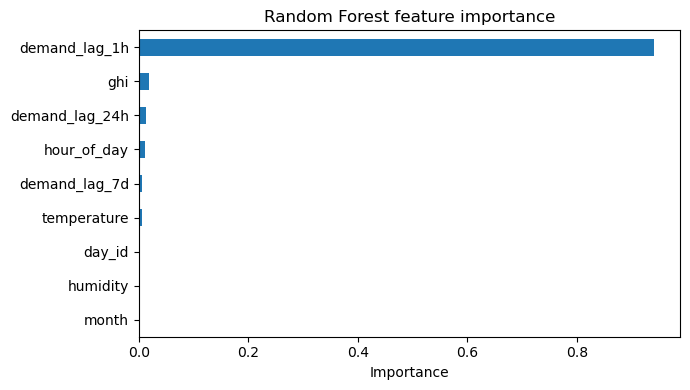

demand_lag_1h     0.941
ghi               0.019
demand_lag_24h    0.013
hour_of_day       0.012
demand_lag_7d     0.006
temperature       0.005
day_id            0.001
humidity          0.001
month             0.001
dtype: float64

In [14]:
importance = (pd.Series(models["Random Forest"].feature_importances_, index=FEATURES)
              .sort_values())
importance.plot(kind="barh", figsize=(7, 4), title="Random Forest feature importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/feature_importance.png", dpi=150)
plt.show()
importance.sort_values(ascending=False).round(3)

## 7. Save results

In [15]:
results_df.to_csv(f"{RESULTS_DIR}/model_results.csv", index=False)
print(results_df.to_string(index=False))

            model  MAE_MW  RMSE_MW  MAPE_%  train_s
Baseline (1h ago)   934.0   1127.0    3.71      0.0
Linear Regression   697.0    875.0    2.83      0.2
    Random Forest   255.0    350.0    1.05     23.7
